In [19]:
import sys
import os

ROOT_DIR = os.path.dirname(os.getcwd())

sys.path.insert(0, ROOT_DIR)

import pandas as pd
import matplotlib.pyplot as plt

from src.greedy import dijkstra
from src.brute_force import BruteForceSearch
from src.performance_monitor import PerformanceMonitor

from data.processed.grafo_rs import grafo

In [20]:
print("CENÁRIO 1 - ENCHENTES NO RIO GRANDE DO SUL")

CENÁRIO 1 - ENCHENTES NO RIO GRANDE DO SUL


In [21]:
resultado = PerformanceMonitor.medir(
    dijkstra,
    grafo,
    4314902
)

resultado

{'resultado': ({4314902: 0,
   4304606: 0.5,
   4318705: 0.9,
   4313409: 0.9,
   4305108: 2.4,
   4316808: 4.4,
   4314407: 7.4,
   4301602: 6.9,
   4323002: 0.7,
   4303509: 1.1},
  {4304606: 4314902,
   4323002: 4314902,
   4313409: 4314902,
   4318705: 4304606,
   4305108: 4313409,
   4303509: 4318705,
   4316808: 4305108,
   4314407: 4316808,
   4301602: 4316808},
  24),
 'tempo_ms': 0.03350013867020607,
 'memoria_mb': 0.000732421875}

In [22]:
busca = BruteForceSearch()

resultado_fb = PerformanceMonitor.medir(
    busca.encontrar_melhor_caminho,
    grafo,
    4314902,
    4305108
)

resultado_fb

{'resultado': {'melhor_caminho': [4314902, 4313409, 4305108],
  'melhor_custo': 2.4,
  'chamadas_recursivas': 19,
  'caminhos_avaliados': 3},
 'tempo_ms': 0.03789970651268959,
 'memoria_mb': 0.000823974609375}

In [23]:
from data.processed.grafo_matopiba import grafo_matopiba

print("CENÁRIO 2 - SECA NA REGIÃO MATOPIBA")

CENÁRIO 2 - SECA NA REGIÃO MATOPIBA


In [24]:
resultado_matopiba = PerformanceMonitor.medir(
    dijkstra,
    grafo_matopiba,
    1001
)

resultado_matopiba

{'resultado': ({1001: 0,
   1002: 1.2,
   1003: 1.5,
   1004: 2.2,
   1005: 3.0,
   1006: 2.8,
   1007: 3.5999999999999996,
   1008: 3.9000000000000004,
   1009: 4.6000000000000005,
   1010: 4.1},
  {1002: 1001,
   1003: 1001,
   1004: 1002,
   1005: 1002,
   1006: 1003,
   1008: 1004,
   1007: 1006,
   1010: 1005,
   1009: 1008},
  24),
 'tempo_ms': 0.043600331991910934,
 'memoria_mb': 0.00089263916015625}

In [25]:
busca = BruteForceSearch()

resultado_fb_matopiba = PerformanceMonitor.medir(
    busca.encontrar_melhor_caminho,
    grafo_matopiba,
    1001,
    1010
)

resultado_fb_matopiba

{'resultado': {'melhor_caminho': [1001, 1002, 1005, 1010],
  'melhor_custo': 4.1,
  'chamadas_recursivas': 33,
  'caminhos_avaliados': 7},
 'tempo_ms': 0.05370005965232849,
 'memoria_mb': 0.001007080078125}

In [26]:
comparacao_cenarios = pd.DataFrame({
    "Cenário": [
        "RS",
        "MATOPIBA"
    ],
    "Tempo Dijkstra (ms)": [
        resultado["tempo_ms"],
        resultado_matopiba["tempo_ms"]
    ]
})

comparacao_cenarios

,Cenário,Tempo Dijkstra (ms)
0,RS,0.0335
1,MATOPIBA,0.0436


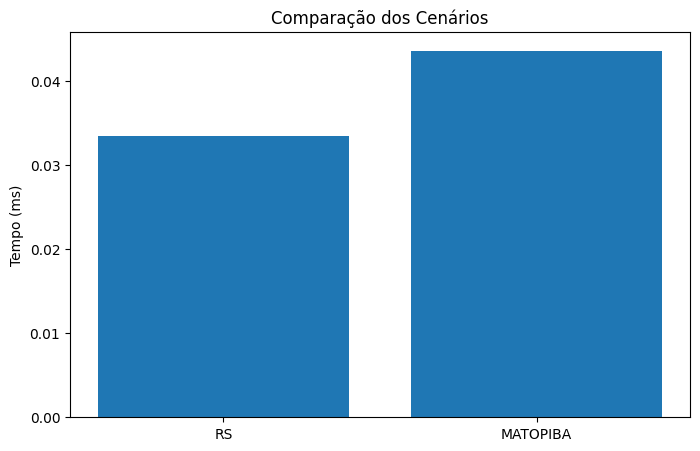

In [27]:
plt.figure(figsize=(8,5))

plt.bar(
    comparacao_cenarios["Cenário"],
    comparacao_cenarios["Tempo Dijkstra (ms)"]
)

plt.title("Comparação dos Cenários")

plt.ylabel("Tempo (ms)")

plt.show()

Conclusão

Os experimentos realizados demonstraram que o algoritmo de Dijkstra foi capaz de identificar corretamente os caminhos de menor custo nos dois cenários analisados: enchentes no Rio Grande do Sul e seca na região MATOPIBA. Em ambos os casos, os resultados obtidos coincidiram com aqueles encontrados pela abordagem de Força Bruta.

A comparação de desempenho evidenciou que o algoritmo guloso apresentou menor custo computacional e melhor escalabilidade, tornando-se mais adequado para aplicações reais que exigem respostas rápidas diante de eventos climáticos extremos.

Além disso, a utilização de estruturas de dados como grafos e árvores binárias de busca permitiu representar e organizar as informações de forma eficiente, contribuindo para a tomada de decisão em cenários de gestão de riscos e desastres naturais.